# 1. Loading and Profiling Data

Every model in this book is downstream of a table. This notebook covers getting that table into TuiML — from files, from pandas, from the built-in catalog, from a generator — and then does the thing most tutorials skip: **looks at the data closely enough to find what is wrong with it.**

**You will learn:**

- what a `Dataset` is and what it carries besides the numbers
- how to load CSV, ARFF, Parquet, JSON and Excel with one function
- how to profile a dataset, and what to profile *for*
- why the diabetes dataset has 374 missing insulin readings that no missing-value check will find
- how to generate synthetic data when you need a known answer

**Prerequisites:** chapter 0.

## 1.1 The Dataset object

TuiML's container is `Dataset`. It is a thin wrapper — the numbers underneath are ordinary NumPy arrays — but it carries the context that makes those numbers interpretable.

In [1]:
from tuiml.datasets import load_diabetes

data = load_diabetes()

print("name          :", data.name)
print("shape         :", data.shape)
print("n_samples     :", data.n_samples)
print("n_features    :", data.n_features)
print("feature_names :", data.feature_names)
print("target_names  :", data.target_names)

name          : pima_diabetes
shape         : (768, 8)
n_samples     : 768
n_features    : 8
feature_names : ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
target_names  : ['tested_negative', 'tested_positive']


`data.X` is the feature matrix, shape `(n_samples, n_features)`. `data.y` is the target vector.

In [2]:
print("X:", type(data.X).__name__, data.X.shape, data.X.dtype)
print("y:", type(data.y).__name__, data.y.shape, data.y.dtype)
print()
print(data.X[:3])

X: ndarray (768, 8) float64
y: ndarray (768,) int64

[[  6.    148.     72.     35.      0.     33.6     0.627  50.   ]
 [  1.     85.     66.     29.      0.     26.6     0.351  31.   ]
 [  8.    183.     64.      0.      0.     23.3     0.672  32.   ]]


Keeping `feature_names` and `target_names` attached matters more than it looks. Column 4 of this matrix is `insu`, serum insulin, and the model output `1` means `tested_positive`. Once you drop that mapping you are working with anonymous numbers, and every error message becomes "something is wrong with column 4".

Convert to pandas whenever you want to look at the data rather than compute on it:

In [3]:
df = data.to_pandas()
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,target
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,tested_positive
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,tested_negative
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,tested_positive
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,tested_negative
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,tested_positive


## 1.2 Loading from files

One function reads every supported format, dispatching on the file extension: `.csv`, `.arff`, `.parquet`, `.json`, `.jsonl`, `.xlsx`.

```python
from tuiml.datasets import load

data = load("patients.csv", target="diagnosis")
data = load("patients.arff")            # ARFF declares its own target
data = load("patients.parquet", target="diagnosis")
data = load("patients.xlsx", target="diagnosis", sheet_name="2026")
```

Format-specific loaders exist too — `load_csv`, `load_arff`, `load_parquet`, `load_json`, `load_excel` — and are worth reaching for when you need options only that format has.

Here is a round trip, so you can see it work rather than take my word for it:

In [4]:
import tempfile
from pathlib import Path
from tuiml.datasets import save_csv, load

tmp = Path(tempfile.mkdtemp())
csv_path = tmp / "diabetes.csv"

save_csv(
    csv_path,
    data.X,
    feature_names=data.feature_names,
    target=data.y,
    target_name="class",
)
print("wrote", csv_path.stat().st_size, "bytes")
print("header:", csv_path.read_text().splitlines()[0])

wrote 32454 bytes
header: preg,plas,pres,skin,insu,mass,pedi,age,class


In [5]:
reloaded = load(csv_path, target_column="class")

print("shape        :", reloaded.shape)
print("feature names:", reloaded.feature_names)
print("round trip preserved values:", (reloaded.X == data.X).all())

shape        : (768, 8)
feature names: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
round trip preserved values: True


> **Remark — the target column.** CSV and Parquet have no notion of which column is the label, so you must say. ARFF does declare it, which is why `load_arff` needs no `target`. Getting this wrong is a quiet failure: your label ends up as a feature, the model learns to read it, and you get a suspiciously perfect score. If a model scores 1.00, suspect this before you celebrate.

## 1.3 The built-in catalog

TuiML ships 25 classic datasets so that examples — including every example in this book — run with no download step.

In [6]:
from tuiml.datasets import list_datasets, get_datasets_by_task, get_dataset_info

print(f"{len(list_datasets())} built-in datasets\n")

classification = get_datasets_by_task("classification")

for name, info in list(classification.items())[:8]:
    print(f"  {name:16s} {info['samples']:5d} rows x {info['features']:2d} features"
          f"  {info['classes']} classes   {info['description'][:38]}")

25 built-in datasets

  iris               150 rows x  4 features  3 classes   Classic flower classification: setosa,
  iris_2d            150 rows x  2 features  3 classes   Iris with reduced features (2D version
  diabetes           768 rows x  8 features  2 classes   Pima Indians diabetes prediction
  breast_cancer      286 rows x  9 features  2 classes   Breast cancer recurrence prediction
  glass              214 rows x  9 features  7 classes   Glass type identification from chemica
  ionosphere         351 rows x 34 features  2 classes   Radar signal classification (good/bad)
  vote               435 rows x 16 features  2 classes   Congressional voting records (democrat
  credit            1000 rows x 20 features  2 classes   German credit risk assessment


In [7]:
get_dataset_info("diabetes")

{'task': 'classification',
 'samples': 768,
 'features': 8,
 'classes': 2,
 'description': 'Pima Indians diabetes prediction',
 'loader': 'load_diabetes'}

Any of these can be named as a string wherever a spec asks for data — `"data": "diabetes"` in chapter 0 was exactly this.

## 1.4 From arrays and DataFrames

If your data is already in memory, wrap it directly.

In [8]:
import numpy as np
from tuiml.datasets import Dataset, from_pandas

rng = np.random.default_rng(0)
X = rng.normal(size=(100, 3))
y = (X[:, 0] + X[:, 1] > 0).astype(int)

manual = Dataset(X=X, y=y, feature_names=["a", "b", "c"], name="toy")
print(manual.shape, manual.feature_names)

(100, 3) ['a', 'b', 'c']


In [9]:
import pandas as pd

frame = pd.DataFrame({
    "age": [34, 51, 29, 66],
    "bmi": [22.1, 31.4, 26.8, 29.0],
    "glucose": [88, 154, 101, 133],
    "diagnosis": [0, 1, 0, 1],
})

wrapped = from_pandas(frame, target_column="diagnosis")

print("shape   :", wrapped.shape)
print("features:", wrapped.feature_names)
print("y       :", wrapped.y)

shape   : (4, 3)
features: ['age', 'bmi', 'glucose']
y       : [0. 1. 0. 1.]


## 1.5 Profiling: looking at the data

Now the part that matters.

You have a table. Before you train anything, you need answers to four questions: **How big is it? What are the columns? Is the target balanced? What is missing?** The first three are easy. The fourth is where datasets lie to you.

Start with the shape of the target, because it determines which metrics are meaningful:

In [10]:
classes, counts = np.unique(data.y, return_counts=True)

for cls, count in zip(classes, counts):
    label = data.target_names[cls]
    print(f"  {cls} {label:16s} {count:4d}  ({100 * count / len(data.y):.1f}%)")

  0 tested_negative   500  (65.1%)
  1 tested_positive   268  (34.9%)


65% negative, 35% positive. Not extreme, but enough that accuracy is a poor summary — the do-nothing model that always predicts "negative" already scores 0.65. Hold that number; chapter 2 uses it as a baseline and chapter 6 deals with imbalance properly.

Now the columns:

In [11]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
plas,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
pres,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
skin,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
insu,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
mass,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
pedi,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00


Read the `min` column. Then read it again.

- `plas` — plasma glucose concentration — minimum **0**
- `pres` — diastolic blood pressure — minimum **0**
- `skin` — triceps skinfold thickness — minimum **0**
- `insu` — serum insulin — minimum **0**
- `mass` — body mass index — minimum **0**

A living person does not have a blood pressure of zero, or a BMI of zero. These are not measurements. They are **missing values that were written down as zeros**, and every automatic missing-value check in existence will walk straight past them, because as far as NumPy is concerned `0.0` is a perfectly good float.

In [12]:
print(f"{'column':8s} {'zeros':>6s} {'%':>7s}   plausible?")
print("-" * 44)

for i, name in enumerate(data.feature_names):
    n_zero = int((data.X[:, i] == 0).sum())
    if n_zero == 0:
        continue
    pct = 100 * n_zero / data.n_samples
    verdict = "yes - real value" if name == "preg" else "NO - missing"
    print(f"{name:8s} {n_zero:6d} {pct:6.1f}%   {verdict}")

column    zeros       %   plausible?
--------------------------------------------
preg        111   14.5%   yes - real value
plas          5    0.7%   NO - missing
pres         35    4.6%   NO - missing
skin        227   29.6%   NO - missing
insu        374   48.7%   NO - missing
mass         11    1.4%   NO - missing


Note the contrast in that table, because it is the whole lesson. `preg` is number of pregnancies, and 111 zeros there are **real** — plenty of people have never been pregnant. `insu` has 374 zeros and every one of them is a gap: nearly **half the dataset** has no insulin reading.

No algorithm can tell those two columns apart. Only someone who knows what the columns *mean* can. This is why profiling is a human activity that happens before modelling, and why "the data is clean, it has no NaNs" is not a statement about the data.

Let us see it:

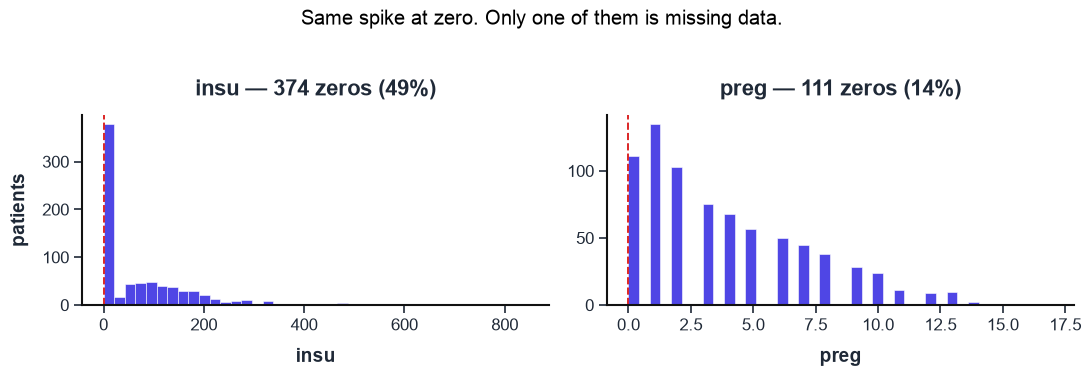

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

for ax, col in zip(axes, ["insu", "preg"]):
    idx = data.feature_names.index(col)
    values = data.X[:, idx]
    ax.hist(values, bins=40, color="#4f46e5", edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="#dc2626", linestyle="--", linewidth=1.4)
    n_zero = int((values == 0).sum())
    ax.set_title(f"{col} — {n_zero} zeros ({100 * n_zero / len(values):.0f}%)")
    ax.set_xlabel(col)

axes[0].set_ylabel("patients")
fig.suptitle("Same spike at zero. Only one of them is missing data.", y=1.04)
fig.tight_layout()
plt.show()

Both columns spike at zero. In `insu` that spike is a hole in the dataset; in `preg` it is the single most common true value. Chapter 3 turns the left-hand spike into explicit missing values and imputes them.

> **Remark — profile before you model, every time.** The cost of skipping this step is not a crash. It is a model that trains without complaint on values it believes are measurements, and a reader of your results who has no way to know. Chapter 3 fixes these zeros and then measures what the fix actually bought — an answer worth waiting for, because it is not the one most tutorials imply.

## 1.6 Generating data

Sometimes you want data whose answer you already know — to test a pipeline, to demonstrate a failure mode, or to control difficulty precisely. TuiML ships generators for that.

In [14]:
from tuiml.datasets import Moons, Blobs, Agrawal

moons = Moons(n_samples=400, noise=0.25, random_state=0).generate()
blobs = Blobs(n_samples=400, n_clusters=3, random_state=0).generate()

print("moons:", moons.X.shape, "classes:", np.unique(moons.y))
print("blobs:", blobs.X.shape, "classes:", np.unique(blobs.y))

moons: (400, 2) classes: [0 1]
blobs: (400, 2) classes: [0 1 2]


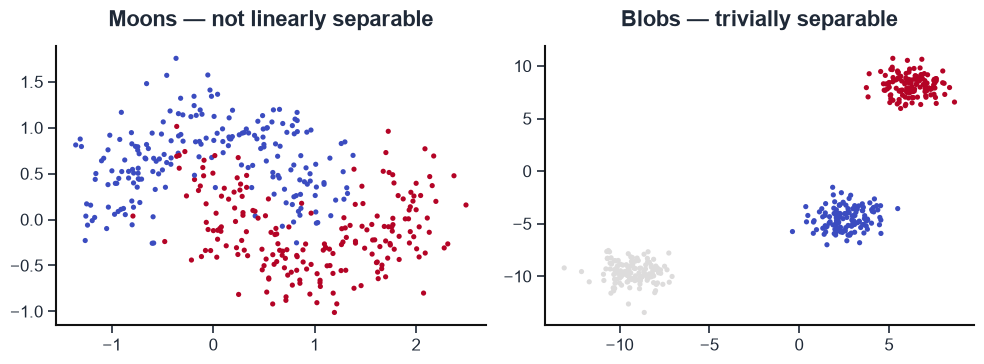

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for ax, ds, title in [(axes[0], moons, "Moons — not linearly separable"),
                      (axes[1], blobs, "Blobs — trivially separable")]:
    ax.scatter(ds.X[:, 0], ds.X[:, 1], c=ds.y, cmap="coolwarm", s=14, edgecolor="none")
    ax.set_title(title)

fig.tight_layout()
plt.show()

These two are a standing test pair for the rest of the book: any classifier should get near-perfect accuracy on the blobs, while the moons separate a linear model from one that can bend. `Agrawal`, `Hyperplane`, `LED`, `RandomRBF`, `Sine` and `Friedman` generate streams with controllable drift, and `Friedman`, `MexicanHat` and `SwissRoll` cover regression.

In [16]:
agrawal = Agrawal(n_samples=1000, function=1, random_state=0).generate()
print("Agrawal:", agrawal.X.shape, "features:", agrawal.feature_names[:5], "...")

Agrawal: (1000, 9) features: ['salary', 'commission', 'age', 'education_level', 'car'] ...


## 1.7 The agent does this first too

The MCP tool `tuiml_profile_data` performs exactly the analysis of section 1.5, and it is almost always an assistant's opening move — before it proposes a model, it looks at the columns, the class balance, and the suspicious values. It flags the impossible zeros in this dataset without being told what the columns mean, because "a physiological measurement of exactly zero, repeated 374 times" is a recognisable pattern.

The point is not that the tool is clever. It is that the profiling step is the same work regardless of who asks for it, which is what makes it worth automating. Chapter 11 shows the tool in a real conversation.

## Recap

- `Dataset` carries `X`, `y`, `feature_names` and `target_names`; keep the names attached.
- `load(path, target=...)` reads CSV, ARFF, Parquet, JSON and Excel by extension. Only ARFF knows its own target.
- 25 datasets ship built in and can be named as a string in any spec.
- Profile for four things: **size, columns, target balance, and what is missing**.
- Missing data does not have to look missing. On the diabetes dataset, 374 insulin readings and 227 skinfold readings are recorded as `0`, and no NaN check will find them.
- Distinguishing a real zero (`preg`) from a missing one (`insu`) requires knowing what the column means. That is your job, not the algorithm's.
- Generators give you data with a known answer, for testing pipelines and demonstrating failure modes.

**Next:** chapter 2 trains on this data and confronts the first number it produces — including why the 65% baseline from section 1.5 makes a 77% accuracy less impressive than it sounds.